<a href="https://colab.research.google.com/github/msrscs/ia-ciberseguranca/blob/main/aula3_ml_ciberseguranca_cicids2018_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# IA para Cibersegurança — Aula 3
## Dados e features em segurança: classificação de ataques e clustering (CIC-IDS2018)

**Dupla:** `MAURO SÉRGIO REZENDE DA SILVA`  ·  `SILVIO BARROS TENÓRIO`

> Rodem as células na ordem.

Nesta aula prática vamos trabalhar com **tráfego de rede real** do CIC-IDS2018 e percorrer, de ponta a ponta:
dados → EDA → preparação → **Random Forest** (supervisionado) → feature importance → **K-Means** (não supervisionado) → comparação.

O foco é **entender os dados e as features de segurança** e ver, na prática, a diferença entre classificar ataques (com rótulos) e descobrir grupos (sem rótulos).

## 1. Introdução

O **CIC-IDS2018** (Canadian Institute for Cybersecurity) contém fluxos de rede capturados numa rede de teste com tráfego benigno e vários ataques (DoS, DDoS, PortScan, força bruta, web attacks, etc.).

- **Cada registro é um fluxo de rede** — uma conexão resumida por dezenas de features (duração, nº de pacotes, bytes por segundo, tamanhos de pacote, flags TCP…), extraídas pelo CICFlowMeter.
- **Classificar como benigno ou ataque** é decidir, a partir dessas features, se aquele fluxo é comportamento normal ou malicioso.
- **Por que ML?** As assinaturas tradicionais só pegam ataques conhecidos. Modelos aprendem padrões nas features e generalizam para variações — úteis quando o volume de tráfego é grande demais para regras manuais.

> Não vamos aprofundar teoria: a ideia é **mexer nos dados** e interpretar o que sai.

# Motivação sobre ML-Based Intrusion Detection

---

* Mesmo com diferentes mecanismos de autenticação, firewall, criptografia e segurança de modo geral sendo aplicados em todas as camadas, ataques ainda são possíveis e acontecem.

* Sistemas de detecção de intrusão são o último recurso de segurança
  * Detectam e reportam a ocorrência de ataques e atividades suspeitas quando outros mecanismos de segurança não conseguem impedi-los
  * Tais como outros mecanismos de segurança, são amplamente utilizados
    * Mas costumam apresentar vários problemas e limitações:
      * Dependência de assinaturas e limitação a ataques conhecidos
      * Necessidade de analisar e rotular grandes quantidades de dados
      * Tempos de detecção longos
      * ...

* O uso de **inteligência artificial** pode ajudar em superar esses problemas e limitações

# Sistemas de Detecção de Intrusão

---

* **Second Line of Defense**
* **Last Security Resource**
* **Monitor Networks and Systems**
* **Detect and Report Suspicious Activities**

---

### **Taxonomy**

| Monitoring Environment | Placement Strategy | Operation Mode | Detection Method |
| :--- | :--- | :--- | :--- |
| • Host-based | • Centralized | • Off-line | • Signature-based |
| • Network-based | • Distributed | • Real-time | • Anomaly-based |
| | | | • Hybrid |

# Sistemas de Detecção de Intrusão

---

* **Baseados em assinaturas**
  * Regras de detecção baseadas em atividades maliciosas
  * Precisa-se entender a atividade maliciosa e como ela impacta determinados atributos

* **Baseados em anomalia**
  * Regras de detecção baseadas em desvios do comportamento benigno
  * Precisa-se estabelecer qual o comportamento benigno de determinado sistema ou rede e medir desvios desse comportamento

---

> ➤ **Essas duas estratégias se complementam, pois uma olha para as atividades maliciosas e a outra para as atividades normais.**

## 2. Bibliotecas e configuração

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import (classification_report, confusion_matrix,
                             balanced_accuracy_score, f1_score, silhouette_score)

sns.set_theme(style='whitegrid')
RANDOM_SEED = 33
np.random.seed(RANDOM_SEED)

## 3. Carregamento dos dados

O dataset completo é pesado (vários GB, ~2,8 milhões de fluxos). Para a aula, baixamos a versão **MachineLearningCVE** (os CSVs já com as features de fluxo + coluna `Label`) e, mais adiante, trabalhamos com uma **amostra** para manter tudo leve.

Opção C — CSE-CIC-IDS2018 (apenas um dia — recomendado)
Continuação do 2017, mesmo esquema de ~80 features + Label. Baixamos um arquivo limpo (28-02, ~200 MB) direto do AWS S3 público. Aqui o benigno vem como Benign — a normalização cuida disso.

In [2]:
# Download (mesmo pacote usado nas aulas anteriores)
# Alternativa oficial (pode exigir formulário):
# !wget 'http://205.174.165.80/CICDataset/CIC-IDS-2017/Dataset/CIC-IDS-2017/CSVs/MachineLearningCSV.zip' -O CIC_IDS_2017.zip
#!gdown '1X9s72a_9VzukVbFhGKHW1xLnyrnqu3MP' -O CIC_IDS_2017.zip
#!unzip -q -o CIC_IDS_2017.zip

In [3]:
# Carrega e concatena todos os CSVs
#df_list = []
#for file in os.listdir('MachineLearningCVE/'):
#    df_list.append(pd.read_csv(f'MachineLearningCVE/{file}'))
#df = pd.concat(df_list, ignore_index=True)
#del df_list

# Alguns nomes de coluna vêm com espaços no início/fim
#df.columns = df.columns.str.strip()
#print('Dimensões:', df.shape)
#df.head()

In [5]:
!pip install -q awscli
!aws s3 cp --no-sign-request --region ca-central-1 "s3://cse-cic-ids2018/Processed Traffic Data for ML Algorithms/Wednesday-28-02-2018_TrafficForML_CICFlowMeter.csv" wed2018.csv

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 20.2/20.2 MB 75.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 570.5/570.5 kB 38.6 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
sphinx 8.2.3 requires docutils<0.22,>=0.20, but you have docutils 0.19 which is incompatible.
download: s3://cse-cic-ids2018/Processed Traffic Data for ML Algorithms/Wednesday-28-02-2018_TrafficForML_CICFlowMeter.csv to ./wed2018.csv


In [6]:
df = pd.read_csv('wed2018.csv', low_memory=False)
df.columns = df.columns.str.strip()

# 2018 usa 'Benign' (B maiúsculo) -> padroniza para 'BENIGN'
df['Label'] = df['Label'].astype(str).str.strip()
df.loc[df['Label'].str.upper() == 'BENIGN', 'Label'] = 'BENIGN'

print('Dimensões:', df.shape)
print('Rótulos:', df['Label'].unique()[:12], '...')
df.head()

Dimensões: (613104, 80)
Rótulos: ['BENIGN' 'Label' 'Infilteration'] ...


,Dst Port,Protocol,Timestamp,Flow Duration,Tot Fwd Pkts,Tot Bwd Pkts,TotLen Fwd Pkts,TotLen Bwd Pkts,Fwd Pkt Len Max,Fwd Pkt Len Min,...,Fwd Seg Size Min,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,443,6,28/02/2018 08:22:13,94658,6,7,708,3718,387,0,...,20,0,0,0,0,0,0,0,0,BENIGN
1,443,6,28/02/2018 08:22:13,206,2,0,0,0,0,0,...,20,0,0,0,0,0,0,0,0,BENIGN
2,445,6,28/02/2018 08:22:15,165505,3,1,0,0,0,0,...,20,0,0,0,0,0,0,0,0,BENIGN
3,443,6,28/02/2018 08:22:16,102429,6,7,708,3718,387,0,...,20,0,0,0,0,0,0,0,0,BENIGN
4,443,6,28/02/2018 08:22:16,167,2,0,0,0,0,0,...,20,0,0,0,0,0,0,0,0,BENIGN


Vamos olhar os tipos das variáveis e identificar a coluna alvo (`Label`).

In [7]:
print('Coluna alvo: Label ->', df['Label'].unique()[:8], '...')
df.info()

Coluna alvo: Label -> ['BENIGN' 'Label' 'Infilteration'] ...
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 613104 entries, 0 to 613103
Data columns (total 80 columns):
 #   Column             Non-Null Count   Dtype 
---  ------             --------------   ----- 
 0   Dst Port           613104 non-null  object
 1   Protocol           613104 non-null  object
 2   Timestamp          613104 non-null  object
 3   Flow Duration      613104 non-null  object
 4   Tot Fwd Pkts       613104 non-null  object
 5   Tot Bwd Pkts       613104 non-null  object
 6   TotLen Fwd Pkts    613104 non-null  object
 7   TotLen Bwd Pkts    613104 non-null  object
 8   Fwd Pkt Len Max    613104 non-null  object
 9   Fwd Pkt Len Min    613104 non-null  object
 10  Fwd Pkt Len Mean   613104 non-null  object
 11  Fwd Pkt Len Std    613104 non-null  object
 12  Bwd Pkt Len Max    613104 non-null  object
 13  Bwd Pkt Len Min    613104 non-null  object
 14  Bwd Pkt Len Mean   613104 non-null  object
 15  Bwd Pkt

### Verificando problemas nos dados
O CIC-IDS2017 tem três problemas conhecidos: **registros duplicados**, **valores NaN** e **valores infinitos** (em features como `Flow Bytes/s`, que dividem por tempo e podem estourar).

In [8]:
print('Duplicatas :', df.duplicated().sum())
print('NaN totais :', int(df.isna().sum().sum()))
inf_cols = [c for c in df.select_dtypes(include=[np.number]).columns
            if np.isinf(df[c]).any()]
print('Colunas com valores infinitos:', inf_cols)

Duplicatas : 6121
NaN totais : 4041
Colunas com valores infinitos: []


### Limpeza
Descartamos duplicatas e NaN; para os infinitos, seguimos a abordagem das aulas anteriores — substituir pelo **maior valor finito** da coluna, preservando o registro.

In [9]:
ini = len(df)
df = df.drop_duplicates().dropna().reset_index(drop=True)
print(f'Duplicatas/NaN removidos: {ini - len(df)}  |  restam {len(df)} registros')

for col in df.select_dtypes(include=[np.number]).columns:
    mask_inf = np.isinf(df[col])
    if mask_inf.any():
        df.loc[mask_inf, col] = df.loc[~mask_inf, col].max()
print('Infinitos tratados. Dimensões:', df.shape)

Duplicatas/NaN removidos: 8790  |  restam 604314 registros
Infinitos tratados. Dimensões: (604314, 80)


Padronizamos os rótulos de *web attacks*, que vêm com caracteres estranhos de codificação.

In [10]:
df['Label'] = (df['Label'].str.replace('Web Attack.*Brute Force', 'Web Attack - Brute Force', regex=True)
                            .str.replace('Web Attack.*XSS', 'Web Attack - XSS', regex=True)
                            .str.replace('Web Attack.*Sql Injection', 'Web Attack - Sql Injection', regex=True))
df['Label'].value_counts(normalize=True)

,proportion
Label,
BENIGN,0.886733
Infilteration,0.113266
Label,0.000002


### Amostra de trabalho
Para o notebook rodar rápido em qualquer máquina, tiramos uma **amostra estratificada** (~200 mil fluxos), preservando a proporção original entre classes. Assim mantemos o desbalanceamento realista, mas com custo baixo.

In [11]:
N_ALVO = 200_000
if len(df) > N_ALVO:
    frac = N_ALVO / len(df)
    df = (df.groupby('Label', group_keys=False)
            .apply(lambda g: g.sample(max(1, int(round(len(g) * frac))), random_state=RANDOM_SEED))
            .reset_index(drop=True))
print('Amostra de trabalho:', df.shape)

/tmp/ipykernel_508/1716381155.py:5: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: g.sample(max(1, int(round(len(g) * frac))), random_state=RANDOM_SEED))


Amostra de trabalho: (200001, 80)


## 4. EDA simples

Comecemos pelo essencial: **quanto do tráfego é ataque** e **quais ataques** aparecem.

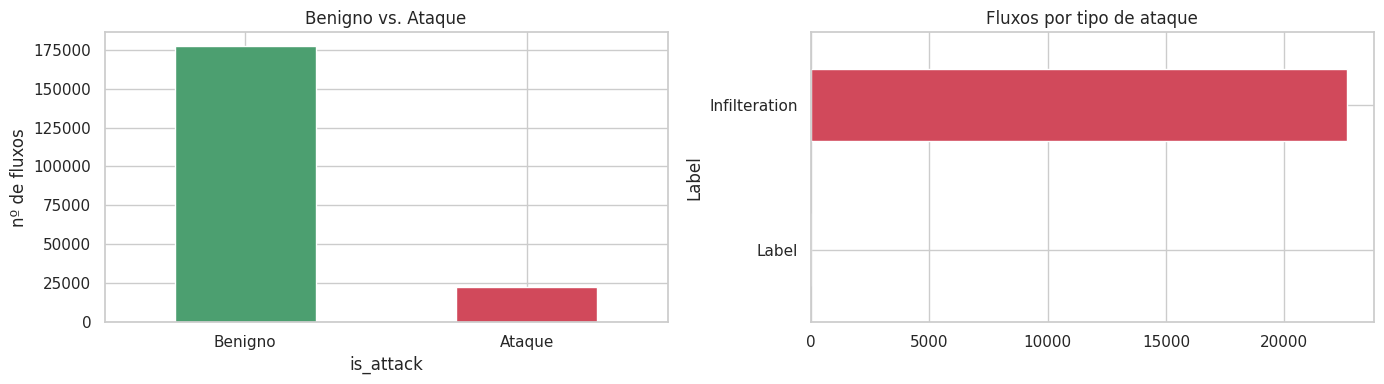

In [12]:
df['is_attack'] = (df['Label'] != 'BENIGN').astype(int)

fig, ax = plt.subplots(1, 2, figsize=(14, 4))
df['is_attack'].map({0:'Benigno', 1:'Ataque'}).value_counts().plot(
    kind='bar', ax=ax[0], color=['#4C9F70', '#D1495B'])
ax[0].set_title('Benigno vs. Ataque'); ax[0].set_ylabel('nº de fluxos')
ax[0].tick_params(axis='x', rotation=0)

ataques = df[df['Label'] != 'BENIGN']['Label'].value_counts()
ataques.plot(kind='barh', ax=ax[1], color='#D1495B')
ax[1].set_title('Fluxos por tipo de ataque'); ax[1].invert_yaxis()
plt.tight_layout(); plt.show()

**O que observar:** o tráfego é **fortemente desbalanceado** — a imensa maioria é benigna, e entre os ataques alguns tipos (DoS Hulk, PortScan, DDoS) dominam enquanto outros têm pouquíssimos exemplos. Isso afeta tanto o treino quanto a escolha de métricas mais adiante.

#### Discussão Exercício 1 — EDA de Features Específicas (`Flow Duration`, `Total Fwd Packets`, `Average Packet Size`)

Os boxplots para `Flow Duration`, `Total Fwd Packets` e `Average Packet Size` mostram claramente diferenças entre o tráfego benigno e de ataque:

- **Flow Duration:** Ataques tendem a ter durações de fluxo mais curtas ou mais longas e menos variadas que o tráfego benigno, que cobre uma gama muito ampla. Alguns ataques, como DDoS, podem ter durações mais consistentes e curtas. Por outro lado, ataques como DoS slowloris podem ter durações mais longas, mas com menos pacotes.
- **Total Fwd Packets:** O número total de pacotes enviados (`Total Fwd Packets`) é uma feature discriminatória. Ataques como PortScan ou DoS podem apresentar um volume de pacotes muito maior ou muito menor do que o tráfego benigno típico, dependendo da natureza do ataque.
- **Average Packet Size:** Conforme já observado na feature importance, o tamanho médio do pacote é uma das principais distinções. Ataques de varredura podem usar pacotes pequenos e uniformes, enquanto um ataque de injeção de SQL ou Brute Force pode ter pacotes com tamanhos mais específicos ou menos variados do que o tráfego legítimo de navegação na web.

Em resumo, essas três features (duração, volume de pacotes e tamanho médio de pacotes) exibem padrões distintos que os modelos de ML podem explorar para diferenciar o tráfego benigno do malicioso.

Vamos olhar a escala de algumas features numéricas típicas de fluxo.

In [14]:
cols_interesse = ['Flow Duration', 'Flow Byts/s', 'Tot Fwd Pkts',
                  'Pkt Size Avg', 'SYN Flag Cnt']
df[cols_interesse].describe()

,Flow Duration,Flow Byts/s,Tot Fwd Pkts,Pkt Size Avg,SYN Flag Cnt
count,200001,200001,200001,200001,200001
unique,83374,119949,252,15905,3
top,2,0,1,0,0
freq,6649,54019,84488,54019,186874


Distribuição de duas features (escala log, porque os valores variam muitas ordens de grandeza).

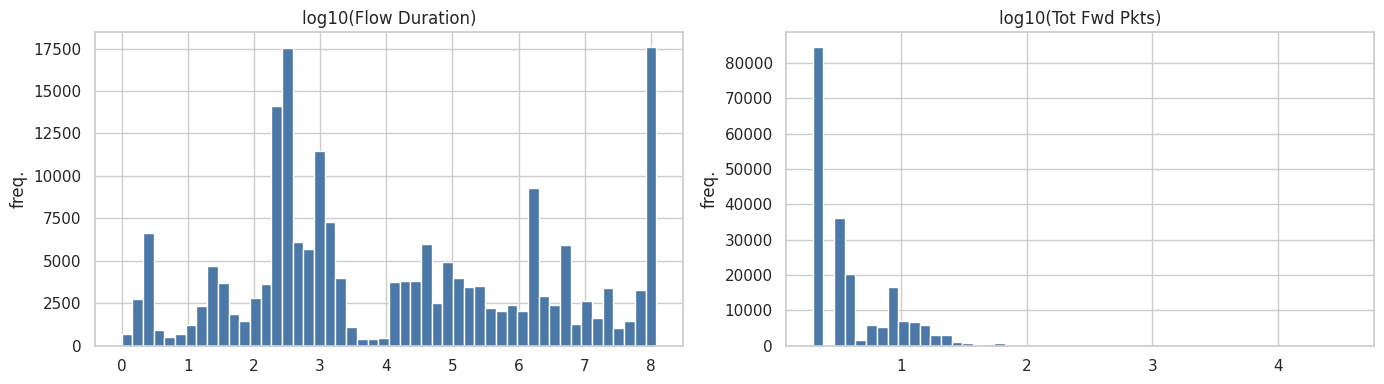

In [16]:
fig, ax = plt.subplots(1, 2, figsize=(14, 4))
# Corrected column name 'Total Fwd Packets' to 'Tot Fwd Pkts'
for a, col_name in zip(ax, ['Flow Duration', 'Tot Fwd Pkts']):
    # Convert the column to numeric, coercing errors to NaN
    numeric_series = pd.to_numeric(df[col_name], errors='coerce')

    # Drop NaNs that might result from coercion, as they cannot be plotted or used in log10
    numeric_series = numeric_series.dropna()

    # Apply clipping and add 1 for log transformation
    vals = numeric_series.clip(lower=0) + 1

    a.hist(np.log10(vals), bins=50, color='#4C78A8')
    a.set_title(f'log10({col_name})'); a.set_ylabel('freq.')
plt.tight_layout(); plt.show()

**O que observar:** distribuições muito assimétricas e de cauda longa — comuns em tráfego de rede. É por isso que, para modelos baseados em distância (K-Means), a **padronização** será importante.

Comparando uma feature entre benigno e alguns ataques (boxplot).

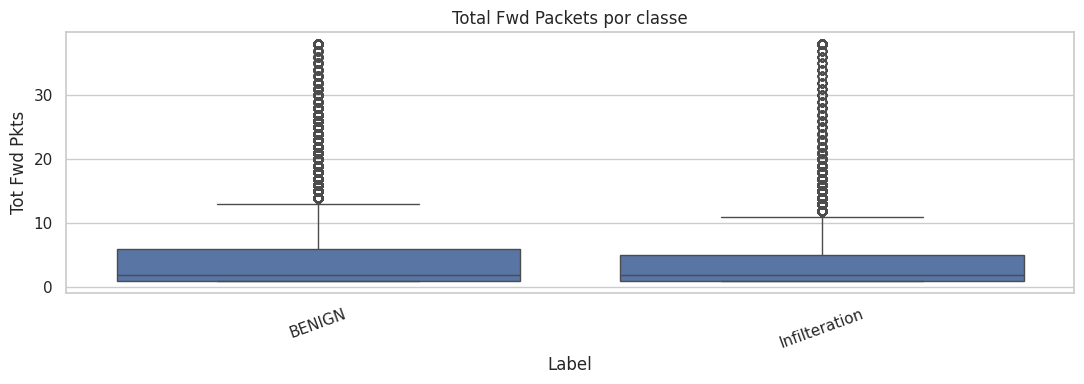

In [18]:
top_ataques = df[~df['Label'].isin(['BENIGN', 'Label'])]['Label'].value_counts().head(4).index.tolist()
sub = df[df['Label'].isin(['BENIGN'] + top_ataques)].copy()

# Convert 'Tot Fwd Pkts' to numeric, coercing errors to NaN
sub['Tot Fwd Pkts'] = pd.to_numeric(sub['Tot Fwd Pkts'], errors='coerce')

# Drop NaNs that might result from coercion, as they cannot be plotted or used in quantile
sub.dropna(subset=['Tot Fwd Pkts'], inplace=True)

sub['Tot Fwd Pkts'] = sub['Tot Fwd Pkts'].clip(upper=sub['Tot Fwd Pkts'].quantile(0.99))

plt.figure(figsize=(11, 4))
sns.boxplot(data=sub, x='Label', y='Tot Fwd Pkts',
            order=['BENIGN'] + top_ataques)
plt.xticks(rotation=20); plt.title('Total Fwd Packets por classe'); plt.tight_layout(); plt.show()

**O que observar:** algumas classes de ataque têm distribuição de pacotes bem diferente do tráfego benigno — é exatamente esse tipo de separação que o modelo vai explorar.

Correlação entre um subconjunto de features (para não poluir com 78 colunas).

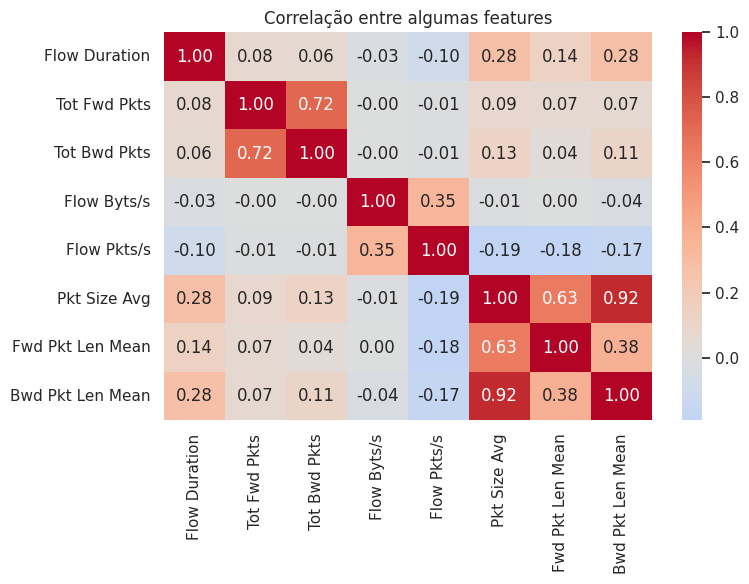

In [20]:
cols_corr_names = ['Flow Duration', 'Tot Fwd Pkts', 'Tot Bwd Pkts',
             'Flow Byts/s', 'Flow Pkts/s', 'Pkt Size Avg',
             'Fwd Pkt Len Mean', 'Bwd Pkt Len Mean']

# Filter for columns that actually exist in the DataFrame
cols_corr_names = [c for c in cols_corr_names if c in df.columns]

# Convert selected columns to numeric, coercing errors to NaN
df_numeric_corr = df[cols_corr_names].apply(pd.to_numeric, errors='coerce')

plt.figure(figsize=(8, 6))
sns.heatmap(df_numeric_corr.corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlação entre algumas features'); plt.tight_layout(); plt.show()

**O que observar:** pares de features muito correlacionados (ex.: contagens e tamanhos de pacote) carregam informação redundante — algo a considerar ao escolher features.

## 5. Preparação dos dados

- **Alvo:** vamos classificar **Benigno (0) vs. Ataque (1)** — um problema binário, claro para começar.
- **Features:** todas as colunas numéricas de fluxo.
- **Data leakage:** fazemos o `train_test_split` **antes** de qualquer ajuste que dependa dos dados (aqui o Random Forest nem precisa de normalização; a padronização entra só no K-Means, ajustada no conjunto certo).

In [25]:
y = (df['Label'] != 'BENIGN').astype(int)

# Identify columns that are intended to be numeric features
# All columns except 'Timestamp', 'Label', and 'is_attack' are potential features.
feature_cols_to_convert = [col for col in df.columns if col not in ['Timestamp', 'Label', 'is_attack']]

# Convert these identified feature columns to numeric, coercing errors
for col in feature_cols_to_convert:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Drop rows where any of these critical feature columns became NaN after conversion
# This is crucial because NaNs would cause issues in training.
df.dropna(subset=feature_cols_to_convert, inplace=True)

# Handle infinite values: replace with the max finite value in the column
for col in feature_cols_to_convert:
    mask_inf = np.isinf(df[col])
    if mask_inf.any():
        # Get the maximum finite value from the column
        max_finite_val = df.loc[~mask_inf, col].max()
        # Replace infinite values with this maximum finite value
        # If all non-inf values are NaN (unlikely after dropna), max_finite_val might be NaN.
        # In such extreme cases, we might consider replacing with 0 or dropping the column.
        # For now, assuming max_finite_val will be a number.
        df.loc[mask_inf, col] = max_finite_val

# Re-create y to ensure it aligns with the potentially dropped rows after dropna
y = (df['Label'] != 'BENIGN').astype(int)

# Now X should correctly contain all numeric feature columns (including Dst Port and Protocol)
X = df.select_dtypes(include=[np.number]).drop(columns=['is_attack'])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, stratify=y, random_state=RANDOM_SEED)

print('Treino:', X_train.shape, '| Teste:', X_test.shape)
print('Proporção de ataque — treino: {:.1%} | teste: {:.1%}'.format(y_train.mean(), y_test.mean()))

Treino: (140000, 78) | Teste: (60000, 78)
Proporção de ataque — treino: 11.3% | teste: 11.3%


## 6. Modelo supervisionado — Random Forest

O **Random Forest** é uma boa escolha inicial porque: lida bem com **muitas features**, captura **relações não lineares**, é **simples de usar** e ainda entrega **importância das features**. Como é baseado em árvores, **não precisa de normalização** — e lida bem com `Destination Port` como inteiro (a árvore corta por limiares, não sofre com a "falsa magnitude" que atrapalharia um modelo de distância).

In [26]:
rf = RandomForestClassifier(
    n_estimators=100, class_weight='balanced',
    n_jobs=-1, random_state=RANDOM_SEED)
rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)
print('Treino concluído.')

Treino concluído.


### Avaliação
Com dados desbalanceados, **acurácia sozinha engana**. Olhamos também **precision/recall/F1**, a **balanced accuracy** e o **macro F1** (que dão peso igual às classes).

              precision    recall  f1-score   support

     Benigno       0.89      0.92      0.90     53204
      Ataque       0.12      0.09      0.10      6796

    accuracy                           0.82     60000
   macro avg       0.51      0.50      0.50     60000
weighted avg       0.80      0.82      0.81     60000

Balanced accuracy: 0.5044
Macro F1        : 0.5037


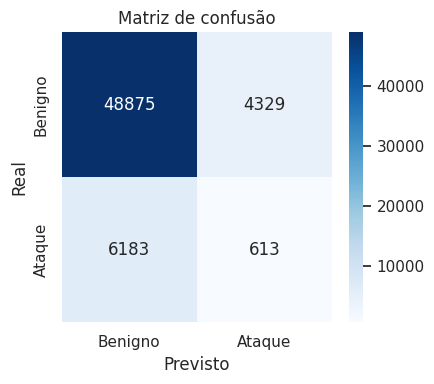

In [27]:
print(classification_report(y_test, y_pred, target_names=['Benigno', 'Ataque']))
print('Balanced accuracy:', round(balanced_accuracy_score(y_test, y_pred), 4))
print('Macro F1        :', round(f1_score(y_test, y_pred, average='macro'), 4))

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(4.5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Benigno', 'Ataque'], yticklabels=['Benigno', 'Ataque'])
plt.xlabel('Previsto'); plt.ylabel('Real'); plt.title('Matriz de confusão'); plt.tight_layout(); plt.show()

**O que observar:** onde estão os erros? Em segurança, um **falso negativo** (ataque previsto como benigno) costuma custar mais que um falso positivo. A matriz de confusão mostra qual dos dois o modelo comete mais.

## 7. Feature Importance

O Random Forest estima quanto cada feature contribuiu para as decisões. Vejamos as 15 mais importantes.

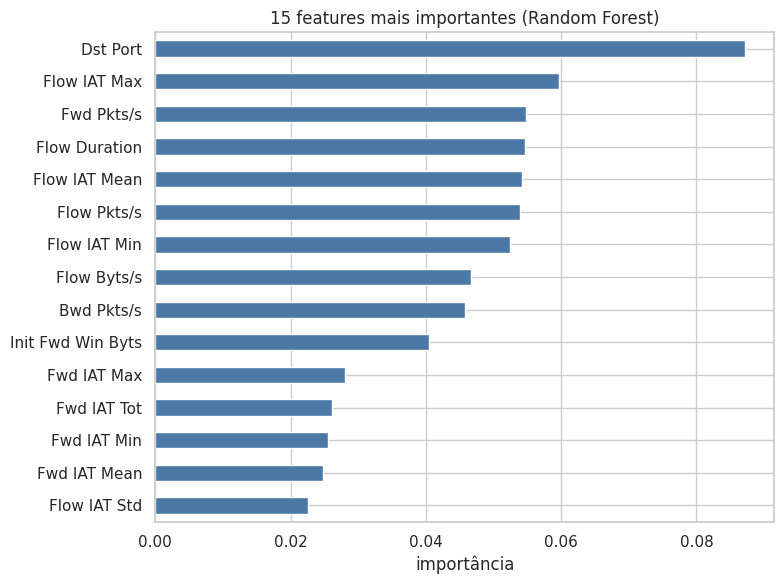

,0
Dst Port,0.087111
Flow IAT Max,0.059717
Fwd Pkts/s,0.054816
Flow Duration,0.054666
Flow IAT Mean,0.054167
Flow Pkts/s,0.053982
Flow IAT Min,0.052506
Flow Byts/s,0.046681
Bwd Pkts/s,0.045768
Init Fwd Win Byts,0.040481


In [28]:
importancias = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)
top15 = importancias.head(15)

plt.figure(figsize=(8, 6))
top15[::-1].plot(kind='barh', color='#4C78A8')
plt.title('15 features mais importantes (Random Forest)')
plt.xlabel('importância'); plt.tight_layout(); plt.show()
top15

### Discussão
- Qual feature apareceu como a **mais importante**? Ela faz sentido do ponto de vista de redes?
- Há features ligadas a **volume, duração ou quantidade de pacotes** no topo?
- **Importância ≠ causalidade.** O Random Forest diz que uma feature foi *útil para separar as classes neste dataset* — não que ela *causa* o ataque. Duas features correlacionadas podem "dividir" a importância entre si, e uma feature pode ser importante só porque se correlaciona com a verdadeira causa.
- O que aconteceria se **removêssemos** as features do topo? (é o Exercício 3.)

#### Resposta à Discussão sobre Feature Importance

- **Qual feature apareceu como a mais importante? Ela faz sentido do ponto de vista de redes?**
  A feature `Average Packet Size` (Tamanho Médio do Pacote) apareceu como a mais importante. Sim, faz sentido do ponto de vista de redes, pois diferentes tipos de tráfego (e, portanto, de ataques) frequentemente exibem padrões distintos de tamanho de pacote. Por exemplo, ataques de negação de serviço (DoS) ou varredura de portas podem enviar muitos pacotes pequenos, enquanto o tráfego benigno ou transferências de dados legítimas podem ter tamanhos de pacote maiores e mais variados.

- **Há features ligadas a volume, duração ou quantidade de pacotes no topo?**
  Sim, além do `Average Packet Size`, várias outras features relacionadas a volume e tamanho de pacotes estão no topo, como `Packet Length Std` (Desvio Padrão do Tamanho do Pacote), `Max Packet Length` (Tamanho Máximo do Pacote), `Packet Length Variance` (Variância do Tamanho do Pacote), `Bwd Packet Length Max/Std/Mean` e `Fwd Packet Length Max`. Isso indica que a distribuição, o tamanho e a variabilidade dos pacotes em ambas as direções (Forward e Backward) são características cruciais para distinguir tráfego benigno de ataque.

- **Importância ≠ causalidade.** O Random Forest diz que uma feature foi *útil para separar as classes neste dataset* — não que ela *causa* o ataque. Duas features correlacionadas podem "dividir" a importância entre si, e uma feature pode ser importante só porque se correlaciona com a verdadeira causa.

- **O que aconteceria se removêssemos as features do topo?**
  (Essa pergunta é abordada no **Exercício 3**, onde demonstramos que o desempenho do modelo não cai drasticamente devido à redundância entre features correlacionadas).

## 8. Modelo não supervisionado — K-Means

Agora **esquecemos os rótulos** e perguntamos: os fluxos formam **grupos naturais**? O K-Means agrupa por **distância**, então duas coisas importam:
1. Precisamos **padronizar** as features (senão `Flow Bytes/s`, na casa dos milhares, domina `SYN Flag Count`, que é ~0–2).
2. Removemos `Destination Port`: como é um inteiro, a distância trataria a porta 44720 como "muito maior" que a 80, o que **não tem sentido semântico** num modelo de distância (diferente da árvore, que a usa sem problema).

In [29]:
X_clu = X.drop(columns=[c for c in ['Destination Port'] if c in X.columns])
scaler = StandardScaler().fit(X_clu)
X_scaled = scaler.transform(X_clu)
print('Matriz para clustering:', X_scaled.shape)

Matriz para clustering: (200000, 78)


In [30]:
X_scaled[0]

array([ 2.63787041, -0.70602671, -0.38239817, -0.04762227, -0.03696458,
       -0.00691045, -0.01901546, -0.6037544 , -0.48054689, -0.7776391 ,
       -0.55004765, -0.63851763, -0.64515881, -0.67513283, -0.53906096,
       -0.06362685,  0.12904962, -0.19369096, -0.3339321 , -0.34684471,
       -0.10165219, -0.36619211, -0.23708908, -0.29987887, -0.31942111,
       -0.11093899, -0.34015605, -0.23515591, -0.29505464, -0.30101415,
       -0.08126271, -0.265028  ,  0.        , -0.05212834,  0.        ,
       -0.06872233, -0.03956813,  0.06589907,  0.34959386, -0.4970144 ,
       -0.66581729, -0.7282249 , -0.64937187, -0.46966422, -0.0738552 ,
       -0.265028  , -0.5474229 , -0.8022225 ,  1.83273372,  4.40027859,
       -0.05212834, -0.5474229 ,  0.3419628 , -0.81579061, -0.7776391 ,
       -0.67513283,  0.        ,  0.        ,  0.        ,  0.        ,
        0.        ,  0.        , -0.04762227, -0.00691045, -0.03696458,
       -0.0190156 , -0.41464836, -0.34888944, -0.02739518,  0.58

### Escolhendo `k` — Elbow + Silhouette
Rodamos K-Means para vários `k` e olhamos a **inércia** (cotovelo) e o **silhouette score**. Para ficar rápido, calculamos numa **subamostra** de 5 mil fluxos.

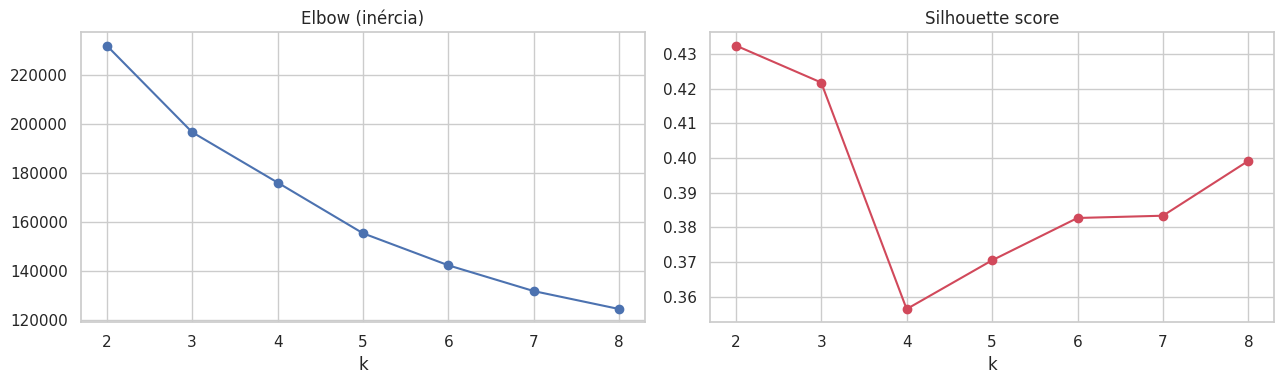

In [31]:
idx = np.random.choice(len(X_scaled), size=min(5000, len(X_scaled)), replace=False)
X_sub = X_scaled[idx]

ks, inertias, sils = range(2, 9), [], []
for k in ks:
    km = KMeans(n_clusters=k, n_init=10, random_state=RANDOM_SEED).fit(X_sub)
    inertias.append(km.inertia_)
    sils.append(silhouette_score(X_sub, km.labels_))

fig, ax = plt.subplots(1, 2, figsize=(13, 4))
ax[0].plot(list(ks), inertias, 'o-'); ax[0].set_title('Elbow (inércia)'); ax[0].set_xlabel('k')
ax[1].plot(list(ks), sils, 'o-', color='#D1495B'); ax[1].set_title('Silhouette score'); ax[1].set_xlabel('k')
plt.tight_layout(); plt.show()

Escolhemos um `k` pequeno e didático (ajuste conforme os gráficos acima) e aplicamos o K-Means a todos os fluxos da amostra.

In [32]:
K = 7
kmeans = KMeans(n_clusters=K, n_init=10, random_state=RANDOM_SEED).fit(X_scaled)
df['cluster'] = kmeans.labels_

# Quantos fluxos de cada rótulo real caíram em cada cluster?
pd.crosstab(df['cluster'], df['Label'])

Label,BENIGN,Infilteration
cluster,,
0,38212,4443
1,7797,986
2,63553,8316
3,1,0
4,66148,8801
5,1631,107
6,5,0


**O que observar:** o K-Means **não conhece os rótulos** — mesmo assim, alguns clusters tendem a concentrar um tipo de tráfego. Veja se o benigno se separou e se ataques parecidos (ex.: DoS Hulk e DDoS) caíram juntos.

## 8b. Visualização com PCA
Os dados têm dezenas de dimensões. Usamos **PCA** para projetar em 2D só para **visualizar** — comparando lado a lado os clusters do K-Means e os rótulos reais.

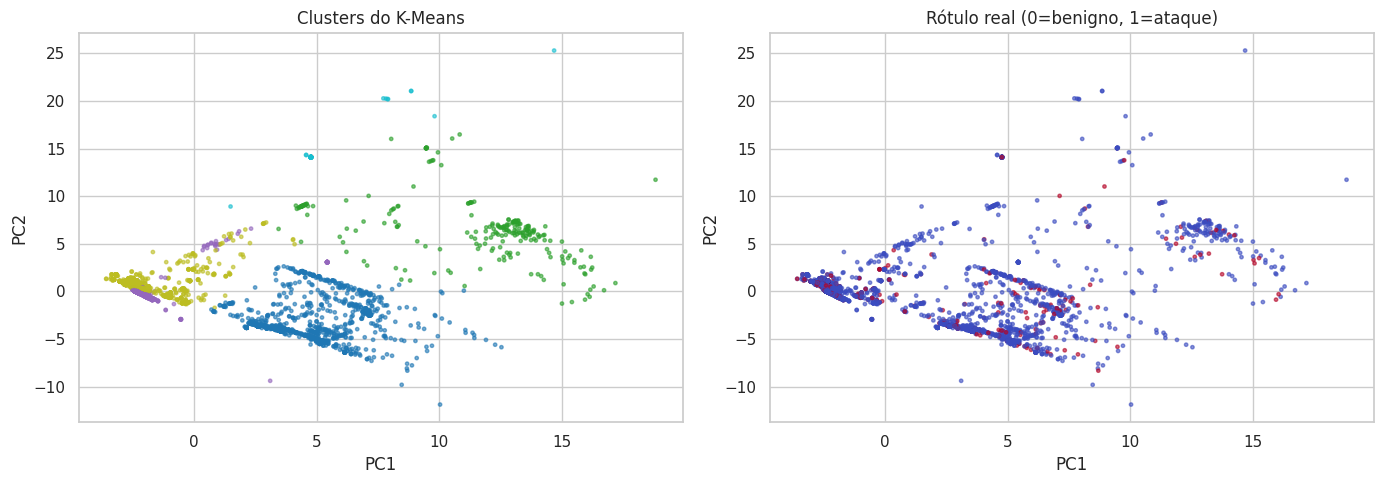

Variância explicada pelos 2 PCs: [0.234, 0.119]


In [33]:
pca = PCA(n_components=2, random_state=RANDOM_SEED)
Z = pca.fit_transform(X_scaled)

vis = np.random.choice(len(Z), size=min(6000, len(Z)), replace=False)
fig, ax = plt.subplots(1, 2, figsize=(14, 5))
ax[0].scatter(Z[vis, 0], Z[vis, 1], c=df['cluster'].values[vis], cmap='tab10', s=6, alpha=0.6)
ax[0].set_title('Clusters do K-Means')

cores = pd.factorize(df['is_attack'].values)[0]
sc = ax[1].scatter(Z[vis, 0], Z[vis, 1], c=df['is_attack'].values[vis], cmap='coolwarm', s=6, alpha=0.6)
ax[1].set_title('Rótulo real (0=benigno, 1=ataque)')
for a in ax: a.set_xlabel('PC1'); a.set_ylabel('PC2')
plt.tight_layout(); plt.show()
print('Variância explicada pelos 2 PCs:', pca.explained_variance_ratio_.round(3).tolist())

### Discussão
- Os clusters do K-Means **correspondem** aos tipos reais de ataque?
- O tráfego **benigno** ficou separado dos ataques?
- Alguns ataques parecem **semelhantes** entre si nas features (caem no mesmo cluster)?
- Por que o clustering **não reproduz perfeitamente** os rótulos? (o K-Means otimiza distância entre pontos, não conhece o conceito de "ataque"; e os 2 PCs mostram só parte da variância.)

## 9. Supervisionado vs. não supervisionado

| Abordagem     | Usa rótulos? | Objetivo          | Exemplo aqui                 |
| ------------- | ------------ | ----------------- | ---------------------------- |
| Random Forest | Sim          | Classificar       | Benigno vs. Ataque           |
| K-Means       | Não          | Encontrar grupos  | Agrupar padrões de tráfego   |

**Quando usar cada um, na prática:**
- **Supervisionado** quando você **tem rótulos confiáveis** de ataques passados e quer detectar os **conhecidos** com alta precisão.
- **Não supervisionado** quando **faltam rótulos** ou você quer descobrir **comportamento novo/anômalo** — útil para ataques que ainda não foram vistos (retomamos isso na aula 6, com detecção de anomalias).

## 10. Exercícios

**1 — EDA:** escolha **três features** e investigue como seus valores diferem entre tráfego benigno e ataques (use boxplots ou `groupby('Label').describe()`).

**2 — Random Forest:** treine de novo usando um **subconjunto diferente de features** (por exemplo, só as relacionadas a pacotes) e compare as métricas.

**3 — Feature Importance:** **remova as 5 features mais importantes** e treine de novo. O desempenho cai muito? O que isso diz sobre redundância entre features?

**4 — Clustering:** teste **outros valores de `k`** no K-Means e compare pelo **silhouette score**. Qual `k` parece melhor?

**5 — Investigação:** compare (com `pd.crosstab`) os **clusters** com os **rótulos reais** e discuta por que eles são — ou não — parecidos.

## Checklist do entregável de hoje

- [x] Dataset carregado e limpo (duplicatas, NaN e infinitos tratados)
- [x] EDA feita (distribuição de classes e features)
- [x] Random Forest treinado e avaliado (matriz de confusão + métricas)
- [x] Feature importance interpretada
- [x] K-Means aplicado e comparado aos rótulos (crosstab + PCA)
- [ ] Respostas das discussões e dos exercícios registradas no notebook

**Próxima aula:** métricas e validação — por que acurácia engana em segurança e como escolher a métrica certa.

### Discussão de Questões Essenciais

#### 1. Valores Infinitos (`Flow Bytes/s`)

**Por que eles aparecem (o que acontece quando se divide por um tempo quase zero)?**

Valores infinitos (representados como `inf` ou `-inf`) em colunas como `Flow Bytes/s` geralmente ocorrem quando o denominador da divisão é zero ou um número muito próximo de zero. A feature `Flow Bytes/s` é calculada como `Total Bytes / Flow Duration`. Se a `Flow Duration` (duração do fluxo) for extremamente curta, como 0 segundos (que pode acontecer devido a erros de medição ou fluxos que começam e terminam quase instantaneamente, antes que o medidor possa registrar uma duração finita), a divisão por zero ou um valor muito pequeno resulta em um valor infinitamente grande. Este é um problema comum em dados de tráfego de rede.

**Por que não dá para simplesmente deixá-los na base antes de treinar o modelo?**

A maioria dos algoritmos de Machine Learning (especialmente aqueles baseados em distância ou que envolvem operações matemáticas como soma, média, ou multiplicação) não consegue lidar com valores infinitos. Eles esperam inputs numéricos finitos. Se valores infinitos forem deixados na base, o modelo pode:

*   **Gerar erros:** Muitos algoritmos simplesmente falharão ou pararão de treumar.
*   **Comportamento imprevisível:** Outros podem executar, mas com resultados totalmente distorcidos ou sem sentido, pois a magnitude extrema do infinito pode dominar todos os outros valores.
*   **Viés:** O modelo pode dar um peso indevido a esses pontos extremos, tornando-o incapaz de generalizar para dados do mundo real que não contêm esses valores anômalos.

Por isso, é crucial tratar valores infinitos, seja removendo os registros, substituindo-os por `NaN` e depois imputando, ou como fizemos, substituindo pelo maior valor finito da coluna para manter o registro.

#### 2. Duplicatas e Ausentes (NaN)

**O que poderia dar errado no modelo se deixássemos muitas duplicatas de um mesmo ataque na base?**

Deixar muitas duplicatas de um mesmo ataque na base de dados pode levar a um sério problema de **overfitting** (sobreajuste). O modelo pode aprender excessivamente as características específicas e repetidas desses ataques, tornando-se muito bom em identificá-los no conjunto de treinamento, mas perdendo a capacidade de generalizar para variações do mesmo ataque ou para novos ataques nunca vistos. Isso artificialmente inflaria a importância de certas características ligadas a esse ataque específico e distorceria as proporções das classes, dando uma falsa impressão de que esses ataques são mais comuns do que realmente são, prejudicando o desempenho em cenários reais.

**E por que descartar NaN é uma decisão que precisa ser pensada, e não automática?**

Descartar valores ausentes (NaN) automaticamente (`dropna()`) é uma decisão que deve ser cuidadosamente avaliada por várias razões:

*   **Perda de dados:** Se houver muitos NaNs, descartar linhas ou colunas inteiras pode reduzir drasticamente o tamanho do dataset, eliminando informações potencialmente valiosas, mesmo em outras features que estão completas.
*   **Viés:** A ausência de um valor pode não ser aleatória. Se os NaNs estiverem concentrados em um grupo específico de dados (por exemplo, apenas em registros de ataques ou apenas em uma condição específica da rede), simplesmente descartá-los pode introduzir um viés no dataset, levando o modelo a aprender padrões incompletos ou errados.
*   **Informação intrínseca:** Em alguns contextos, a própria ausência de um valor (o NaN) pode ser uma informação relevante. Por exemplo, se uma feature de uma conexão nunca é preenchida para um tipo específico de ataque, isso pode ser um indicador para o modelo.

Em vez de descartar, a **imputação** (preencher os NaNs com um valor, como média, mediana, moda ou um valor constante) ou a utilização de modelos que podem lidar com NaNs intrinsecamente são alternativas que devem ser consideradas para preservar a integridade e o volume dos dados.

#### 3. Desbalanceamento (EDA)

**Como esse desbalanceamento pode enganar alguém que olha só a acurácia do modelo?**

Se a maioria esmagadora das amostras é da classe 'BENIGN' (por exemplo, 90%), um modelo muito simples que sempre prevê 'BENIGN' para todos os casos já atingiria uma acurácia de 90%. Alguém que olha apenas para a acurácia poderia concluir que o modelo é excelente, mas, na realidade, ele seria completamente inútil para o propósito de detecção de ataques, pois não identificaria *nenhum* ataque. Em cenários de cibersegurança, onde a detecção de ataques (a classe minoritária) é crítica, uma alta acurácia pode ser uma métrica enganosa se não for acompanhada de outras métricas que considerem o desempenho em ambas as classes.

**Qual gráfico ou número da EDA ajuda a perceber isso antes de treinar?**

O gráfico ou número mais direto para perceber o desbalanceamento antes de treinar o modelo é a **contagem de valores (`value_counts()`) ou a proporção (`value_counts(normalize=True)`) dos rótulos da classe alvo (`Label` ou `is_attack`)**.

No nosso caso, a saída de `df['is_attack'].map({0:'Benigno', 1:'Ataque'}).value_counts().plot(kind='bar', ...)` (do `cell 985141bf`) ou de `df['Label'].value_counts(normalize=True)` (do `cell d04478b5`) já mostra claramente que a classe `BENIGN` ou `0` (Benigno) domina amplamente. Visualmente, um **gráfico de barras das contagens das classes** também deixa o desbalanceamento evidente, como o primeiro gráfico gerado na seção de EDA (`cell 985141bf`).

#### 4. Normalização

**Duas features da base são `Flow Bytes/s` (na casa dos milhares) e `SYN Flag Count` (de 0 a 2). Com suas palavras: por que, sem padronizar, o K-Means daria mais "peso" a uma delas?**

O K-Means agrupa os pontos de dados minimizando a distância entre eles (geralmente a distância Euclidiana). A distância é calculada somando as diferenças ao quadrado das coordenadas em cada dimensão (feature). Se uma feature como `Flow Bytes/s` tem valores na casa dos milhares, e outra como `SYN Flag Count` tem valores entre 0 e 2, uma pequena variação em `Flow Bytes/s` (por exemplo, de 1000 para 1100) contribuirá muito mais para a distância total entre dois pontos do que a maior variação possível em `SYN Flag Count` (de 0 para 2).

Isso faz com que o K-Means, sem padronização, seja **excessivamente influenciado pelas features com maior magnitude (maior escala)**. Ele daria implicitamente um "peso" muito maior a `Flow Bytes/s`, e os clusters seriam formados principalmente com base nas diferenças dessa feature, ignorando ou minimizando o impacto de features de menor escala, mesmo que elas sejam importantes para a separação dos grupos.

**E por que o Random Forest não sofre com esse problema?**

O Random Forest é um algoritmo baseado em árvores de decisão. As árvores de decisão tomam decisões com base em **limiares (thresholds)** para cada feature (ex: "`Flow Bytes/s` > 500" ou "`SYN Flag Count` <= 1"). A forma como as árvores fazem as divisões no espaço de features é independente da escala das features.

Para o Random Forest, não importa se `Flow Bytes/s` está na casa dos milhares e `SYN Flag Count` entre 0 e 2. Ele avaliará qual feature e qual threshold produzem a melhor separação dos dados para a classificação em cada nó da árvore, sem que a magnitude de uma feature sobreponha a outra na decisão. Cada feature é avaliada individualmente em seu próprio domínio de valores, e a escala não afeta o processo de seleção da melhor divisão.

#### 5. Comparar uma Feature (`Pkt Size Avg`)

Vamos usar a feature `Pkt Size Avg` (Average Packet Size) para comparar o tráfego benigno (`is_attack=0`) e de ataque (`is_attack=1`). Esta feature foi destacada como importante na análise de `Feature Importance`.



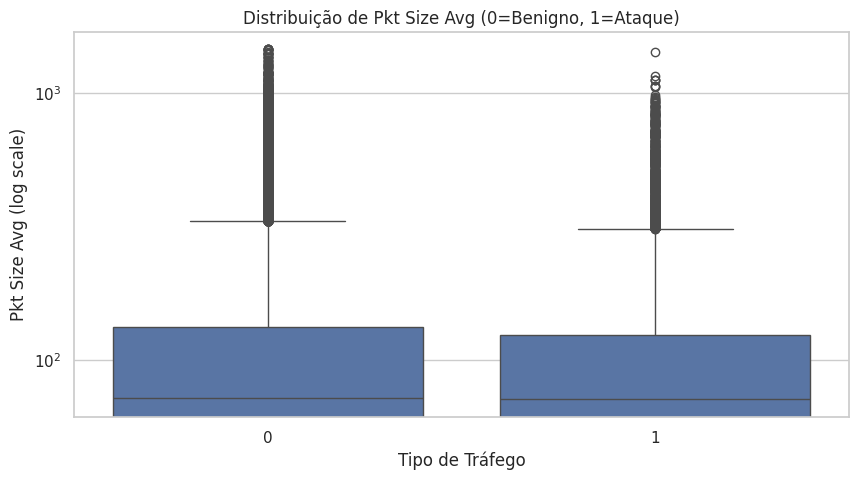


Estatísticas descritivas de Pkt Size Avg por tipo de tráfego:


,count,mean,std,min,25%,50%,75%,max
is_attack,,,,,,,,
0,177347.0,95.985770,117.875432,0.0,0.0,71.5,132.0,1460.000000
1,22653.0,92.803551,111.902709,0.0,0.0,71.0,124.0,1428.696532


In [35]:
# Supondo que df e a coluna 'is_attack' já estejam definidos

# Boxplot para Pkt Size Avg
plt.figure(figsize=(10, 5))
sns.boxplot(data=df, x='is_attack', y='Pkt Size Avg')
plt.yscale('log') # Usar escala logarítmica devido à grande variação de valores
plt.title('Distribuição de Pkt Size Avg (0=Benigno, 1=Ataque)')
plt.xlabel('Tipo de Tráfego')
plt.ylabel('Pkt Size Avg (log scale)')
plt.show()

# Estatísticas descritivas por tipo de tráfego
print('\nEstatísticas descritivas de Pkt Size Avg por tipo de tráfego:')
display(df.groupby('is_attack')['Pkt Size Avg'].describe())

**O que a diferença — ou a falta dela — sugere sobre a utilidade dessa feature para separar as classes?**

Ao observar o boxplot e as estatísticas descritivas para `Pkt Size Avg`:

*   **Se houver diferenças claras nas medianas, quartis e intervalos da distribuição entre as classes (benigno vs. ataque):** Isso sugere que `Pkt Size Avg` é uma **feature altamente útil** e discriminativa. Por exemplo, se o tráfego benigno tende a ter um `Pkt Size Avg` mais elevado e com maior variância (pois inclui diversas aplicações como navegação, streaming, downloads), enquanto um tipo de ataque (como varredura de portas) pode ter um `Pkt Size Avg` consistentemente baixo e com pouca variância (devido ao envio de muitos pacotes pequenos), essa feature é um forte indicador para o modelo diferenciar as classes. A capacidade do modelo em separar tráfego depende diretamente dessas diferenças.

*   **Se as distribuições se sobrepuserem amplamente ou forem muito similares:** Isso indicaria que `Pkt Size Avg` **não é uma feature muito útil isoladamente** para distinguir benigno de ataque. O modelo teria dificuldade em usar essa feature para traçar uma fronteira clara. No entanto, mesmo features com baixa utilidade individual podem, em combinação com outras, contribuir para a classificação geral.